# Import necessary libraries

In [239]:
import pandas as pd
import numpy as np

# Load the dataset 

In [240]:
df = pd.read_csv('streamworks_user_data.csv')

# Explore the dataset

In [241]:
df.head(5)

,user_id,age,gender,signup_date,last_active_date,country,subscription_type,average_watch_hours,mobile_app_usage_pct,complaints_raised,received_promotions,referred_by_friend,is_churned,monthly_fee
0,1001.0,56.0,Other,02-04-25,13-07-25,France,Standard,42.6,77.4,1.0,No,No,1.0,10.99
1,1002.0,69.0,Male,02-01-23,13-07-25,India,Basic,65.3,98.0,4.0,No,Yes,1.0,5.99
2,1003.0,46.0,Male,21-08-22,13-07-25,UK,Premium,40.1,47.8,0.0,No,Yes,1.0,13.99
3,1004.0,32.0,Other,14-09-23,13-07-25,Germany,Premium,5.8,53.2,1.0,Yes,Yes,1.0,13.99
4,1005.0,60.0,Female,29-07-23,13-07-25,India,Standard,32.7,16.8,5.0,No,Yes,0.0,9.99


In [242]:
df.shape

(1500, 14)

In [243]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1498 non-null   float64
 1   age                   1497 non-null   float64
 2   gender                1499 non-null   object 
 3   signup_date           1498 non-null   object 
 4   last_active_date      1498 non-null   object 
 5   country               1497 non-null   object 
 6   subscription_type     1497 non-null   object 
 7   average_watch_hours   1496 non-null   float64
 8   mobile_app_usage_pct  1498 non-null   float64
 9   complaints_raised     1497 non-null   float64
 10  received_promotions   1497 non-null   object 
 11  referred_by_friend    1497 non-null   object 
 12  is_churned            1499 non-null   float64
 13  monthly_fee           1355 non-null   float64
dtypes: float64(7), object(7)
memory usage: 164.2+ KB


In [244]:
df.isnull().sum()

user_id                   2
age                       3
gender                    1
signup_date               2
last_active_date          2
country                   3
subscription_type         3
average_watch_hours       4
mobile_app_usage_pct      2
complaints_raised         3
received_promotions       3
referred_by_friend        3
is_churned                1
monthly_fee             145
dtype: int64

In [245]:
df.duplicated().sum()

np.int64(0)

In [246]:
df.describe(include='all')

,user_id,age,gender,signup_date,last_active_date,country,subscription_type,average_watch_hours,mobile_app_usage_pct,complaints_raised,received_promotions,referred_by_friend,is_churned,monthly_fee
count,1498.000000,1497.000000,1499,1498,1498,1497,1497,1496.000000,1498.000000,1497.000000,1497,1497,1499.000000,1355.000000
unique,NaN,NaN,3,819,1,6,3,NaN,NaN,NaN,2,2,NaN,NaN
top,NaN,NaN,Female,19-09-23,13-07-25,Canada,Basic,NaN,NaN,NaN,No,Yes,NaN,NaN
freq,NaN,NaN,510,6,1498,262,505,NaN,NaN,NaN,763,752,NaN,NaN
mean,1750.871829,43.738811,NaN,NaN,NaN,NaN,NaN,39.903342,51.414419,2.498330,NaN,NaN,0.234156,10.180406
std,433.060980,15.083920,NaN,NaN,NaN,NaN,NaN,22.978288,28.580117,1.706829,NaN,NaN,0.423612,3.310705
min,1001.000000,18.000000,NaN,NaN,NaN,NaN,NaN,0.500000,0.000000,0.000000,NaN,NaN,0.000000,5.990000
25%,1376.250000,31.000000,NaN,NaN,NaN,NaN,NaN,19.450000,27.100000,1.000000,NaN,NaN,0.000000,5.990000
50%,1750.500000,44.000000,NaN,NaN,NaN,NaN,NaN,40.300000,52.700000,2.000000,NaN,NaN,0.000000,9.990000
75%,2125.750000,56.000000,NaN,NaN,NaN,NaN,NaN,59.800000,76.200000,4.000000,NaN,NaN,0.000000,13.990000


# Data Cleaning 

In [247]:
#standardizing text columns 
df.gender = df.gender.str.strip().str.title()
df.country = df.country.str.strip().str.title()
df.subscription_type = df.subscription_type.str.strip().str.title()
df.received_promotions = df.received_promotions.str.strip().str.title()
df.referred_by_friend = df.referred_by_friend.str.strip().str.title()

In [248]:
df.head(5)

,user_id,age,gender,signup_date,last_active_date,country,subscription_type,average_watch_hours,mobile_app_usage_pct,complaints_raised,received_promotions,referred_by_friend,is_churned,monthly_fee
0,1001.0,56.0,Other,02-04-25,13-07-25,France,Standard,42.6,77.4,1.0,No,No,1.0,10.99
1,1002.0,69.0,Male,02-01-23,13-07-25,India,Basic,65.3,98.0,4.0,No,Yes,1.0,5.99
2,1003.0,46.0,Male,21-08-22,13-07-25,Uk,Premium,40.1,47.8,0.0,No,Yes,1.0,13.99
3,1004.0,32.0,Other,14-09-23,13-07-25,Germany,Premium,5.8,53.2,1.0,Yes,Yes,1.0,13.99
4,1005.0,60.0,Female,29-07-23,13-07-25,India,Standard,32.7,16.8,5.0,No,Yes,0.0,9.99


In [249]:
#Convert the date fileds to a standard date value 
df.signup_date = pd.to_datetime(df.signup_date, errors = 'coerce')
df.last_active_date = pd.to_datetime(df.last_active_date, errors = 'coerce')

C:\Users\Public\Documents\iSkysoft\CreatorTemp\ipykernel_15888\3742333188.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.signup_date = pd.to_datetime(df.signup_date, errors = 'coerce')


In [250]:
df.tail(5)

,user_id,age,gender,signup_date,last_active_date,country,subscription_type,average_watch_hours,mobile_app_usage_pct,complaints_raised,received_promotions,referred_by_friend,is_churned,monthly_fee
1495,2496.0,40.0,Female,2023-11-26,2025-07-13,Canada,Standard,7.5,88.7,0.0,No,No,0.0,9.99
1496,2497.0,54.0,Male,2025-12-02,2025-07-13,Usa,Basic,48.7,42.0,NaN,Yes,Yes,1.0,NaN
1497,2498.0,28.0,Other,2023-01-03,2025-07-13,Uk,Premium,12.6,49.7,0.0,No,No,1.0,13.99
1498,2499.0,23.0,Female,2022-10-24,2025-07-13,Usa,Basic,3.0,91.7,2.0,No,Yes,0.0,5.99
1499,2500.0,35.0,Other,2023-01-26,2025-07-13,Canada,Basic,77.7,77.6,2.0,No,Yes,0.0,5.99


In [251]:
#check weather the last active date is after the signup date 
df['invalid_date_order'] = df.last_active_date < df.signup_date
df[df['invalid_date_order'] == True]
df['invalid_date_order'].sum()

np.int64(48)

In [252]:
df.tail(5)

,user_id,age,gender,signup_date,last_active_date,country,subscription_type,average_watch_hours,mobile_app_usage_pct,complaints_raised,received_promotions,referred_by_friend,is_churned,monthly_fee,invalid_date_order
1495,2496.0,40.0,Female,2023-11-26,2025-07-13,Canada,Standard,7.5,88.7,0.0,No,No,0.0,9.99,False
1496,2497.0,54.0,Male,2025-12-02,2025-07-13,Usa,Basic,48.7,42.0,NaN,Yes,Yes,1.0,NaN,True
1497,2498.0,28.0,Other,2023-01-03,2025-07-13,Uk,Premium,12.6,49.7,0.0,No,No,1.0,13.99,False
1498,2499.0,23.0,Female,2022-10-24,2025-07-13,Usa,Basic,3.0,91.7,2.0,No,Yes,0.0,5.99,False
1499,2500.0,35.0,Other,2023-01-26,2025-07-13,Canada,Basic,77.7,77.6,2.0,No,Yes,0.0,5.99,False


In [253]:
#change the float data columns to numeric fields 
df.age = pd.to_numeric(df.age)
df.user_id = pd.to_numeric(df.user_id)
df.average_watch_hours = pd.to_numeric(df.average_watch_hours)
df.mobile_app_usage_pct = pd.to_numeric(df.mobile_app_usage_pct)

In [254]:
#validate age column 
df['invalid_age'] = df.age <= 0 
df[df['invalid_age'] == True]
df['invalid_age'].sum()

np.int64(0)

In [255]:
#validate watch hour column 
df['invalid_watch_hr'] = df.average_watch_hours < 0 
df[df['invalid_watch_hr'] == True]
df['invalid_watch_hr'].sum()

np.int64(0)

In [256]:
#validate mobile pct column 
df['invalid_mobile_pct'] = df.mobile_app_usage_pct < 0 
df[df['invalid_mobile_pct'] == True]
df['invalid_mobile_pct'].sum()

np.int64(0)

In [257]:
#validate monthly fee column 
df['invalid_monthly_fee'] = df.monthly_fee < 0 
df[df['invalid_monthly_fee'] == True]
df['invalid_monthly_fee'].sum()

np.int64(0)

In [258]:
df.tail(5)

,user_id,age,gender,signup_date,last_active_date,country,subscription_type,average_watch_hours,mobile_app_usage_pct,complaints_raised,received_promotions,referred_by_friend,is_churned,monthly_fee,invalid_date_order,invalid_age,invalid_watch_hr,invalid_mobile_pct,invalid_monthly_fee
1495,2496.0,40.0,Female,2023-11-26,2025-07-13,Canada,Standard,7.5,88.7,0.0,No,No,0.0,9.99,False,False,False,False,False
1496,2497.0,54.0,Male,2025-12-02,2025-07-13,Usa,Basic,48.7,42.0,NaN,Yes,Yes,1.0,NaN,True,False,False,False,False
1497,2498.0,28.0,Other,2023-01-03,2025-07-13,Uk,Premium,12.6,49.7,0.0,No,No,1.0,13.99,False,False,False,False,False
1498,2499.0,23.0,Female,2022-10-24,2025-07-13,Usa,Basic,3.0,91.7,2.0,No,Yes,0.0,5.99,False,False,False,False,False
1499,2500.0,35.0,Other,2023-01-26,2025-07-13,Canada,Basic,77.7,77.6,2.0,No,Yes,0.0,5.99,False,False,False,False,False


In [259]:
df['gender'].unique()

array(['Other', 'Male', 'Female', nan], dtype=object)

In [260]:
df['country'].unique()

array(['France', 'India', 'Uk', 'Germany', 'Usa', 'Canada', nan],
      dtype=object)

In [261]:
df['subscription_type'].unique()

array(['Standard', 'Basic', 'Premium', nan], dtype=object)

In [262]:
#Handling missing values 
df['gender'] = df['gender'].fillna("Not Selected")
df['country'] = df['country'].fillna("Not Selected")
df['subscription_type'] = df['subscription_type'].fillna("Not Selected")

In [263]:
df.isnull().sum()

user_id                   2
age                       3
gender                    0
signup_date               2
last_active_date          2
country                   0
subscription_type         0
average_watch_hours       4
mobile_app_usage_pct      2
complaints_raised         3
received_promotions       3
referred_by_friend        3
is_churned                1
monthly_fee             145
invalid_date_order        0
invalid_age               0
invalid_watch_hr          0
invalid_mobile_pct        0
invalid_monthly_fee       0
dtype: int64

In [264]:
df = df.drop_duplicates()

In [265]:
df.shape

(1500, 19)

In [266]:
#filling missing age values with mode
mode_age = df['age'].mode()[0]
df['age'] = df['age'].fillna(mode_age)

In [267]:
# remove rows with missing user id 
df = df.dropna(subset =['user_id'])

In [268]:
df.isnull().sum()

user_id                   0
age                       0
gender                    0
signup_date               2
last_active_date          2
country                   0
subscription_type         0
average_watch_hours       4
mobile_app_usage_pct      2
complaints_raised         3
received_promotions       3
referred_by_friend        3
is_churned                1
monthly_fee             145
invalid_date_order        0
invalid_age               0
invalid_watch_hr          0
invalid_mobile_pct        0
invalid_monthly_fee       0
dtype: int64

In [269]:
df.head(5)

,user_id,age,gender,signup_date,last_active_date,country,subscription_type,average_watch_hours,mobile_app_usage_pct,complaints_raised,received_promotions,referred_by_friend,is_churned,monthly_fee,invalid_date_order,invalid_age,invalid_watch_hr,invalid_mobile_pct,invalid_monthly_fee
0,1001.0,56.0,Other,2025-02-04,2025-07-13,France,Standard,42.6,77.4,1.0,No,No,1.0,10.99,False,False,False,False,False
1,1002.0,69.0,Male,2023-02-01,2025-07-13,India,Basic,65.3,98.0,4.0,No,Yes,1.0,5.99,False,False,False,False,False
2,1003.0,46.0,Male,2022-08-21,2025-07-13,Uk,Premium,40.1,47.8,0.0,No,Yes,1.0,13.99,False,False,False,False,False
3,1004.0,32.0,Other,2023-09-14,2025-07-13,Germany,Premium,5.8,53.2,1.0,Yes,Yes,1.0,13.99,False,False,False,False,False
4,1005.0,60.0,Female,2023-07-29,2025-07-13,India,Standard,32.7,16.8,5.0,No,Yes,0.0,9.99,False,False,False,False,False


# Feature Engineering and Encoding Part

In [270]:
df['tenure_days'] = df['last_active_date'] - df['signup_date']

In [271]:
df['is_loyal'] = df['tenure_days'] > pd.Timedelta(days=180)

In [272]:
df.head(5)

,user_id,age,gender,signup_date,last_active_date,country,subscription_type,average_watch_hours,mobile_app_usage_pct,complaints_raised,...,referred_by_friend,is_churned,monthly_fee,invalid_date_order,invalid_age,invalid_watch_hr,invalid_mobile_pct,invalid_monthly_fee,tenure_days,is_loyal
0,1001.0,56.0,Other,2025-02-04,2025-07-13,France,Standard,42.6,77.4,1.0,...,No,1.0,10.99,False,False,False,False,False,159 days,False
1,1002.0,69.0,Male,2023-02-01,2025-07-13,India,Basic,65.3,98.0,4.0,...,Yes,1.0,5.99,False,False,False,False,False,893 days,True
2,1003.0,46.0,Male,2022-08-21,2025-07-13,Uk,Premium,40.1,47.8,0.0,...,Yes,1.0,13.99,False,False,False,False,False,1057 days,True
3,1004.0,32.0,Other,2023-09-14,2025-07-13,Germany,Premium,5.8,53.2,1.0,...,Yes,1.0,13.99,False,False,False,False,False,668 days,True
4,1005.0,60.0,Female,2023-07-29,2025-07-13,India,Standard,32.7,16.8,5.0,...,Yes,0.0,9.99,False,False,False,False,False,715 days,True


In [273]:
#Encoding the columns for ML
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['subscription_type_encoded'] = le.fit_transform(df['subscription_type'])
df['is_loyal_encoded'] = le.fit_transform(df['is_loyal'])

In [274]:
#Encoding columns that are non Categorical 
df_encoded = pd.get_dummies(df,
                            columns=['gender', 'country', 'received_promotions', 'referred_by_friend'],
                            drop_first=True
                            )

In [275]:
df.tail(5)

,user_id,age,gender,signup_date,last_active_date,country,subscription_type,average_watch_hours,mobile_app_usage_pct,complaints_raised,...,monthly_fee,invalid_date_order,invalid_age,invalid_watch_hr,invalid_mobile_pct,invalid_monthly_fee,tenure_days,is_loyal,subscription_type_encoded,is_loyal_encoded
1495,2496.0,40.0,Female,2023-11-26,2025-07-13,Canada,Standard,7.5,88.7,0.0,...,9.99,False,False,False,False,False,595 days,True,3,1
1496,2497.0,54.0,Male,2025-12-02,2025-07-13,Usa,Basic,48.7,42.0,NaN,...,NaN,True,False,False,False,False,-142 days,False,0,0
1497,2498.0,28.0,Other,2023-01-03,2025-07-13,Uk,Premium,12.6,49.7,0.0,...,13.99,False,False,False,False,False,922 days,True,2,1
1498,2499.0,23.0,Female,2022-10-24,2025-07-13,Usa,Basic,3.0,91.7,2.0,...,5.99,False,False,False,False,False,993 days,True,0,1
1499,2500.0,35.0,Other,2023-01-26,2025-07-13,Canada,Basic,77.7,77.6,2.0,...,5.99,False,False,False,False,False,899 days,True,0,1


In [276]:
df.loc[df['tenure_days'] < pd.Timedelta(0), 'tenure_days'] = pd.NA

In [277]:
df.tail(5)

,user_id,age,gender,signup_date,last_active_date,country,subscription_type,average_watch_hours,mobile_app_usage_pct,complaints_raised,...,monthly_fee,invalid_date_order,invalid_age,invalid_watch_hr,invalid_mobile_pct,invalid_monthly_fee,tenure_days,is_loyal,subscription_type_encoded,is_loyal_encoded
1495,2496.0,40.0,Female,2023-11-26,2025-07-13,Canada,Standard,7.5,88.7,0.0,...,9.99,False,False,False,False,False,595 days,True,3,1
1496,2497.0,54.0,Male,2025-12-02,2025-07-13,Usa,Basic,48.7,42.0,NaN,...,NaN,True,False,False,False,False,NaT,False,0,0
1497,2498.0,28.0,Other,2023-01-03,2025-07-13,Uk,Premium,12.6,49.7,0.0,...,13.99,False,False,False,False,False,922 days,True,2,1
1498,2499.0,23.0,Female,2022-10-24,2025-07-13,Usa,Basic,3.0,91.7,2.0,...,5.99,False,False,False,False,False,993 days,True,0,1
1499,2500.0,35.0,Other,2023-01-26,2025-07-13,Canada,Basic,77.7,77.6,2.0,...,5.99,False,False,False,False,False,899 days,True,0,1


In [278]:
df['watch_per_fee_ratio'] = df['average_watch_hours'] / df['monthly_fee'] 

In [279]:
#inorder to calculate the heavy_mobile_user we need a treshold value that is 75 pct per week
df['heavy_mobile_user'] = df['mobile_app_usage_pct'] > 75

In [280]:
df.tail(5)

,user_id,age,gender,signup_date,last_active_date,country,subscription_type,average_watch_hours,mobile_app_usage_pct,complaints_raised,...,invalid_age,invalid_watch_hr,invalid_mobile_pct,invalid_monthly_fee,tenure_days,is_loyal,subscription_type_encoded,is_loyal_encoded,watch_per_fee_ratio,heavy_mobile_user
1495,2496.0,40.0,Female,2023-11-26,2025-07-13,Canada,Standard,7.5,88.7,0.0,...,False,False,False,False,595 days,True,3,1,0.750751,True
1496,2497.0,54.0,Male,2025-12-02,2025-07-13,Usa,Basic,48.7,42.0,NaN,...,False,False,False,False,NaT,False,0,0,NaN,False
1497,2498.0,28.0,Other,2023-01-03,2025-07-13,Uk,Premium,12.6,49.7,0.0,...,False,False,False,False,922 days,True,2,1,0.900643,False
1498,2499.0,23.0,Female,2022-10-24,2025-07-13,Usa,Basic,3.0,91.7,2.0,...,False,False,False,False,993 days,True,0,1,0.500835,True
1499,2500.0,35.0,Other,2023-01-26,2025-07-13,Canada,Basic,77.7,77.6,2.0,...,False,False,False,False,899 days,True,0,1,12.971619,True


In [281]:
df['tenure_days'].describe(include='all')

count                           1446
mean     561 days 21:59:30.124481328
std      323 days 00:02:17.158848628
min                  6 days 00:00:00
25%                283 days 06:00:00
50%                567 days 00:00:00
75%                821 days 12:00:00
max               1281 days 00:00:00
Name: tenure_days, dtype: object

In [282]:
df['is_loyal'].describe(include='all')

count     1498
unique       2
top       True
freq      1228
Name: is_loyal, dtype: object

In [283]:
df['watch_per_fee_ratio'].describe(include='all')

count    1349.000000
mean        4.446301
std         3.197715
min         0.033356
25%         2.002002
50%         3.875917
75%         6.105551
max        13.338898
Name: watch_per_fee_ratio, dtype: float64

In [284]:
df['heavy_mobile_user'].describe(include='all')

count      1498
unique        2
top       False
freq       1105
Name: heavy_mobile_user, dtype: object

In [285]:
df['user_id'] = df['user_id'].astype(int)
df['age'] = df['age'].astype(int)

In [286]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1498 entries, 0 to 1499
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype          
---  ------                     --------------  -----          
 0   user_id                    1498 non-null   int64          
 1   age                        1498 non-null   int64          
 2   gender                     1498 non-null   object         
 3   signup_date                1496 non-null   datetime64[ns] 
 4   last_active_date           1496 non-null   datetime64[ns] 
 5   country                    1498 non-null   object         
 6   subscription_type          1498 non-null   object         
 7   average_watch_hours        1494 non-null   float64        
 8   mobile_app_usage_pct       1496 non-null   float64        
 9   complaints_raised          1495 non-null   float64        
 10  received_promotions        1495 non-null   object         
 11  referred_by_friend         1495 non-null   object         
 1

# Statistical Analysis & Insights

In [287]:
# Chi-square test for gender
from scipy.stats import chi2_contingency

table = pd.crosstab(df['is_churned'], df['gender'])

chi2, p, dof, expected = chi2_contingency(table)

print('Chi2:', round(chi2,2))
print('p-value:', round(p,2))
print('Degrees of freedom:', round(dof,2))
print('Expected counts:\n', expected)


Chi2: 7.68
p-value: 0.05
Degrees of freedom: 3
Expected counts:
 [[3.89995324e+02 3.69307949e+02 7.66199065e-01 3.86930528e+02]
 [1.19004676e+02 1.12692051e+02 2.33800935e-01 1.18069472e+02]]


In [288]:
# Chi-square test for received_promotions
from scipy.stats import chi2_contingency

table = pd.crosstab(df['is_churned'], df['received_promotions'])

chi2, p, dof, expected = chi2_contingency(table)

print('Chi2:', round(chi2,2))
print('p-value:', round(p,2))
print('Degrees of freedom:', round(dof,2))
print('Expected counts:\n', expected)


Chi2: 2.07
p-value: 0.15
Degrees of freedom: 1
Expected counts:
 [[584.24832664 562.75167336]
 [176.75167336 170.24832664]]


In [289]:
# Chi-square test for referred_by_friend
from scipy.stats import chi2_contingency

table = pd.crosstab(df['is_churned'], df['referred_by_friend'])

chi2, p, dof, expected = chi2_contingency(table)

print('Chi2:', round(chi2,2))
print('p-value:', round(p,2))
print('Degrees of freedom:', round(dof,2))
print('Expected counts:\n', expected)


Chi2: 0.6
p-value: 0.44
Degrees of freedom: 1
Expected counts:
 [[569.81939799 575.18060201]
 [174.18060201 175.81939799]]


In [290]:
#t-test value
from scipy.stats import ttest_ind

df_clean = df[['is_churned', 'average_watch_hours']].dropna()

churned = df_clean[df_clean['is_churned']==1]['average_watch_hours']
retained = df_clean[df_clean['is_churned']==0]['average_watch_hours']

t_stat, p_value = ttest_ind(churned, retained, equal_var=False)

print("t-statistic:", round(t_stat,2))
print("p-value:", round(p_value,2))

t-statistic: -0.14
p-value: 0.89


In [291]:
#correlation Analysis
df_clean = df.dropna()

df_numeric = df_clean.select_dtypes(include='number')

corr_matr = df_numeric.corr()

print(round(corr_matr,2))

                           user_id   age  average_watch_hours  \
user_id                       1.00 -0.01                -0.03   
age                          -0.01  1.00                 0.03   
average_watch_hours          -0.03  0.03                 1.00   
mobile_app_usage_pct         -0.02 -0.01                 0.00   
complaints_raised            -0.07  0.03                -0.00   
is_churned                    0.01  0.02                -0.03   
monthly_fee                  -0.05 -0.00                -0.02   
tenure_days                  -0.03  0.01                -0.05   
subscription_type_encoded    -0.06 -0.01                -0.01   
is_loyal_encoded             -0.01  0.01                -0.01   
watch_per_fee_ratio           0.01  0.03                 0.82   

                           mobile_app_usage_pct  complaints_raised  \
user_id                                   -0.02              -0.07   
age                                       -0.01               0.03   
average_w

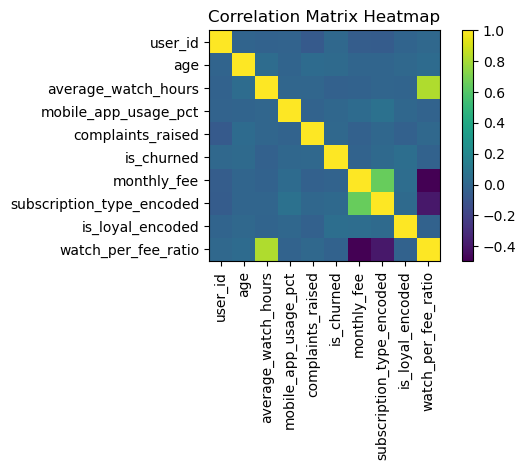

In [292]:
# to visualise key differences between churned and active users
import matplotlib.pyplot as plt
import seaborn as sns

df_clean = df.dropna()

# select numeric columns only
df_numeric = df_clean.select_dtypes(include=['int64', 'float64'])

# compute correlation matrix
corr_matrix = df_numeric.corr()

# plot heatmap
plt.figure()
plt.imshow(corr_matrix)
plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

C:\Users\Public\Documents\iSkysoft\CreatorTemp\ipykernel_15888\69761689.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['churn_status'] = df_clean['is_churned'].map({1: 'Churned', 0: 'Active'})


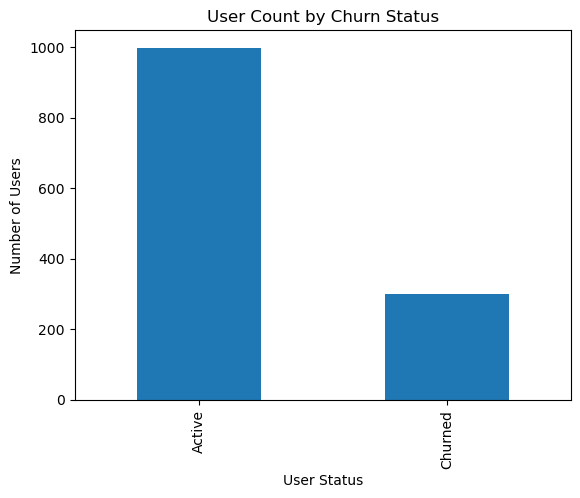

In [293]:
# to visualise key differences between churned and active users
import matplotlib.pyplot as plt
import seaborn as sns

df_clean['churn_status'] = df_clean['is_churned'].map({1: 'Churned', 0: 'Active'})

churn_counts = df_clean['churn_status'].value_counts()

churn_counts.plot(kind='bar')
plt.xlabel('User Status')
plt.ylabel('Number of Users')
plt.title('User Count by Churn Status')
plt.show()

#  Predictive Modelling

Linear Regression Result:

	Coefficent: 0.08
	RMSE: 22.5
	R²: -0.0
	Intercept: $ 39.91


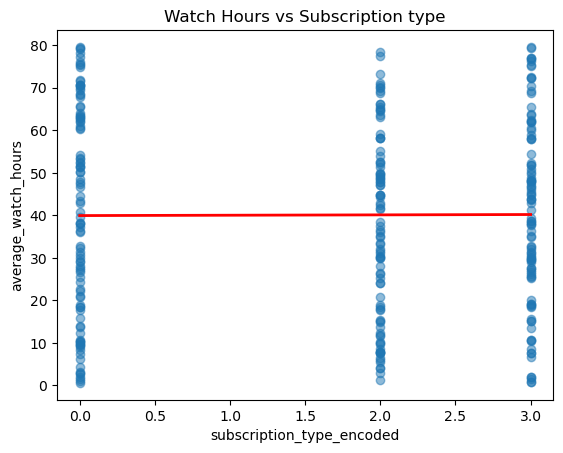

In [336]:
#Linear Regression 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
#prepare the data 
df_clean = df.dropna(subset=['average_watch_hours', 'subscription_type_encoded']) 

x = df_clean[['subscription_type_encoded']] 
#df_clean['tenure_days_numeric'] = df_clean['tenure_days'].dt.total_seconds() / (24*3600)
#x = df_clean[['tenure_days_numeric']]
y = df_clean['average_watch_hours']

#y = df_clean['tenure_days'] 

#split data into 80% train and 20% test 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=42) 

#step-1- create model 
lr_model = LinearRegression() 

#step-2- Train model 
lr_model.fit(x_train,y_train) 

#step-3- make predictions 
y_pred = lr_model.predict(x_test) 

#step-4- visualize result 
plt.scatter(x_test, y_test, alpha=0.5) 
plt.plot(x_test, y_pred, color='red', linewidth=2) 
plt.title('Watch Hours vs Subscription type') 
plt.ylabel('average_watch_hours') 
plt.xlabel('subscription_type_encoded')

#step-5- Evaluating the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('Linear Regression Result:\n')
print('\tCoefficent:', round(lr_model.coef_[0],2))
print('\tRMSE:', round(rmse,2))
print('\tR²:', round(r2,2))
print('\tIntercept: $', round(lr_model.intercept_,2))


Linear Regression Result:

	Coefficent: 0.08
	RMSE: 22.5
	R²: -0.0
	Intercept: $ 39.91


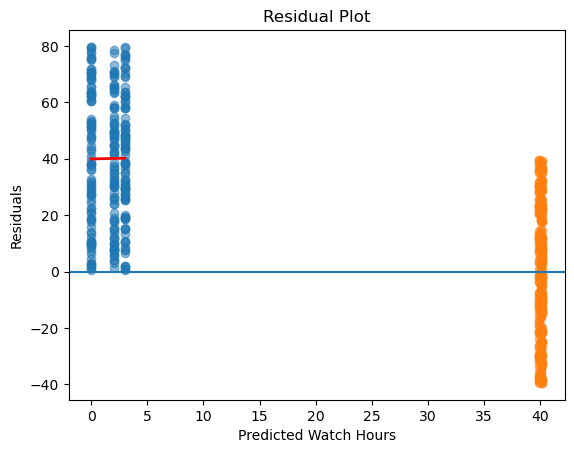

In [337]:
#Linear Regression with evaluation metrics
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
#prepare the data 
df_clean = df.dropna(subset=['average_watch_hours', 'subscription_type_encoded']) 

x = df_clean[['subscription_type_encoded']] 
#df_clean['tenure_days_numeric'] = df_clean['tenure_days'].dt.total_seconds() / (24*3600)
#x = df_clean[['tenure_days_numeric']]
y = df_clean['average_watch_hours']

#split data into 80% train and 20% test 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=42) 

#step-1- create model 
lr_model = LinearRegression() 

#step-2- Train model 
lr_model.fit(x_train,y_train) 

#step-3- make predictions 
y_pred = lr_model.predict(x_test) 

#step-4- visualize result 
plt.scatter(x_test, y_test, alpha=0.5) 
plt.plot(x_test, y_pred, color='red', linewidth=2) 
plt.title('Watch Hours vs Subscription Type') 
plt.ylabel('average_watch_hours') 
plt.xlabel('subscription_type_encoded')

#step-5- Evaluating the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('Linear Regression Result:\n')
print('\tCoefficent:', round(lr_model.coef_[0],2))
print('\tRMSE:', round(rmse,2))
print('\tR²:', round(r2,2))
print('\tIntercept: $', round(lr_model.intercept_,2))

#step-6- Residuals plot 
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0)
plt.xlabel('Predicted Watch Hours')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()


Confusion Matrix:
 [[191   0]
 [ 69   0]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.73      1.00      0.85       191
         1.0       0.00      0.00      0.00        69

    accuracy                           0.73       260
   macro avg       0.37      0.50      0.42       260
weighted avg       0.54      0.73      0.62       260



D:\DataScience\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\DataScience\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\DataScience\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


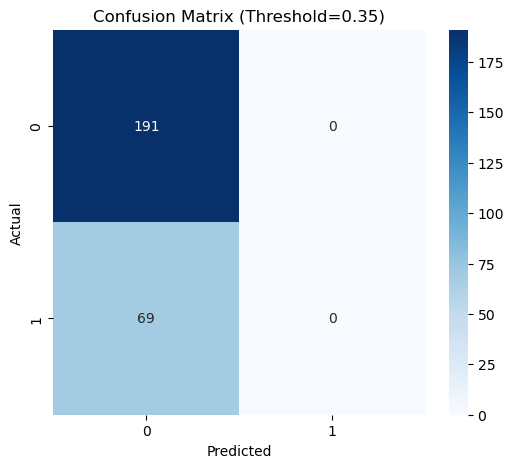

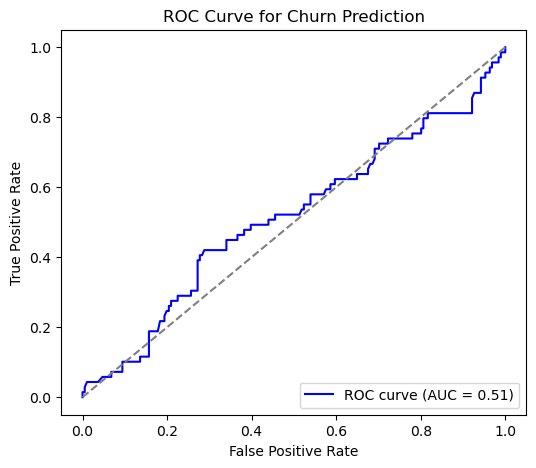

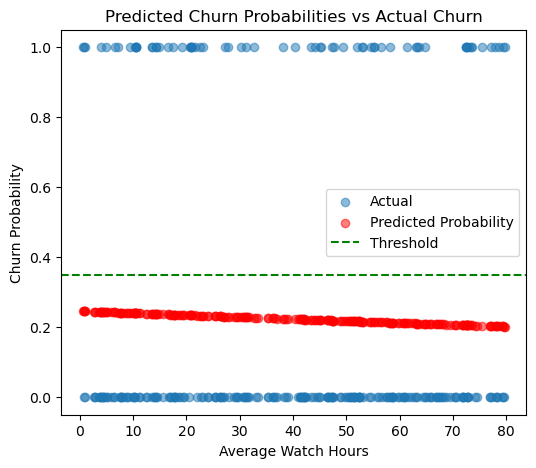

In [330]:
#Logestic Regression Average Watch Hours vs churn
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

#prepare the data 
df_clean = df_clean.dropna()

x = df_clean[['average_watch_hours']]
#df_clean['tenure_days_numeric'] = df_clean['tenure_days'].dt.total_seconds() / (24*3600)
y = df_clean['is_churned']

#split data into 80% train and 20% test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=42) 

#step-1- create model
log_model = LogisticRegression(random_state = 42)

#step-2- train model
log_model.fit(x_train, y_train)

#step-3- make predictions 
y_pred = log_model.predict(x_test)
y_pred_proba = log_model.predict_proba(x_test)[:,1]

# Step 4: Apply realistic threshold based on business logic
threshold = 0.35
y_pred = (y_pred_proba >= threshold).astype(int)

# Step 5: Evaluate model
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Step 6: Visualize confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Threshold={threshold})')
plt.show()

# Step 7: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Churn Prediction')
plt.legend(loc='lower right')
plt.show()

# Step 8: Visualize predicted probabilities vs actual
plt.figure(figsize=(6,5))
plt.scatter(x_test, y_test, alpha=0.5, label='Actual')
plt.scatter(x_test, y_pred_proba, alpha=0.5, label='Predicted Probability', color='red')
plt.axhline(threshold, color='green', linestyle='--', label='Threshold')
plt.xlabel('Average Watch Hours')
plt.ylabel('Churn Probability')
plt.title('Predicted Churn Probabilities vs Actual Churn')
plt.legend()
plt.show()


Confusion Matrix:
 [[191   0]
 [ 69   0]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.73      1.00      0.85       191
         1.0       0.00      0.00      0.00        69

    accuracy                           0.73       260
   macro avg       0.37      0.50      0.42       260
weighted avg       0.54      0.73      0.62       260



D:\DataScience\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\DataScience\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\DataScience\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


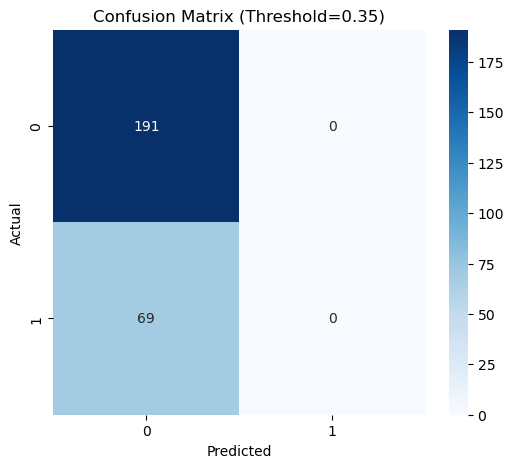

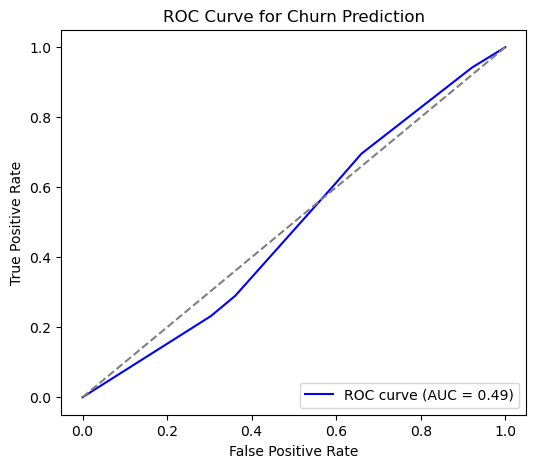

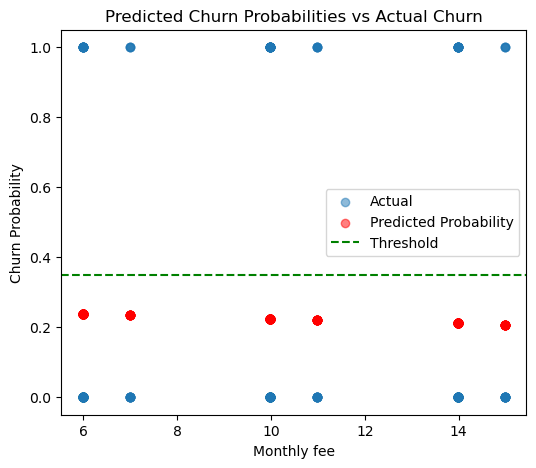

In [329]:
#Logestic Regression monthly fee vs churn
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

#prepare the data 
df_clean = df_clean.dropna()

x = df_clean[['monthly_fee']]
#df_clean['tenure_days_numeric'] = df_clean['tenure_days'].dt.total_seconds() / (24*3600)
y = df_clean['is_churned']

#split data into 80% train and 20% test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=42) 

#step-1- create model
log_model = LogisticRegression(random_state = 42)

#step-2- train model
log_model.fit(x_train, y_train)

#step-3- make predictions 
y_pred = log_model.predict(x_test)
y_pred_proba = log_model.predict_proba(x_test)[:,1]

# Step 4: Apply realistic threshold based on business logic
threshold = 0.35
y_pred = (y_pred_proba >= threshold).astype(int)

# Step 5: Evaluate model
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Step 6: Visualize confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Threshold={threshold})')
plt.show()

# Step 7: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Churn Prediction')
plt.legend(loc='lower right')
plt.show()

# Step 8: Visualize predicted probabilities vs actual
plt.figure(figsize=(6,5))
plt.scatter(x_test, y_test, alpha=0.5, label='Actual')
plt.scatter(x_test, y_pred_proba, alpha=0.5, label='Predicted Probability', color='red')
plt.axhline(threshold, color='green', linestyle='--', label='Threshold')
plt.xlabel('Monthly fee')
plt.ylabel('Churn Probability')
plt.title('Predicted Churn Probabilities vs Actual Churn')
plt.legend()
plt.show()


Confusion Matrix:
 [[191   0]
 [ 69   0]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.73      1.00      0.85       191
         1.0       0.00      0.00      0.00        69

    accuracy                           0.73       260
   macro avg       0.37      0.50      0.42       260
weighted avg       0.54      0.73      0.62       260



D:\DataScience\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\DataScience\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\DataScience\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


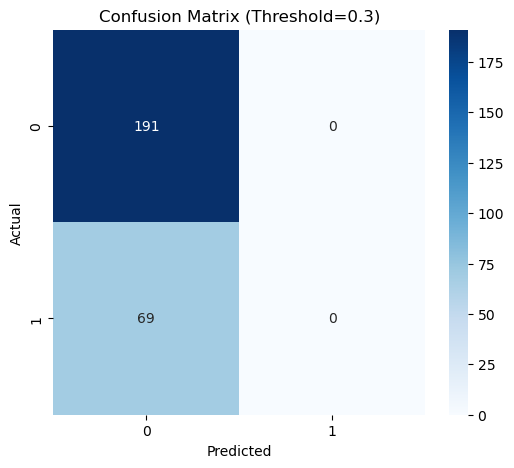

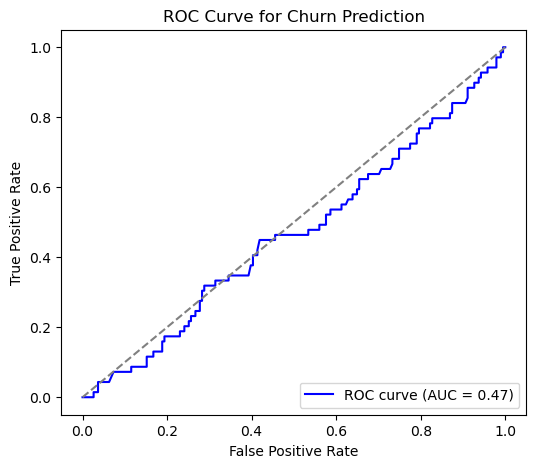

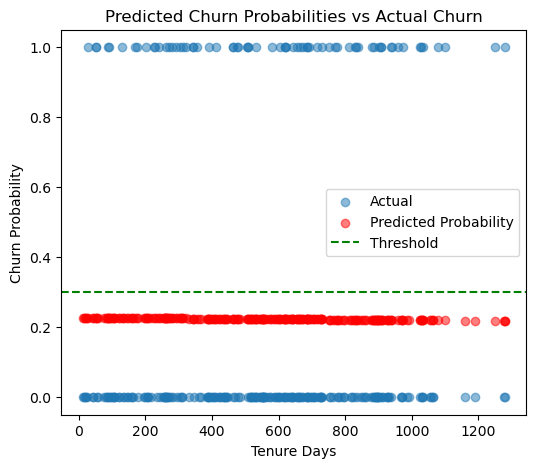

In [326]:
#Logestic Regression tenuer days vs churn
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

#prepare the data 
df_clean = df_clean.dropna()

#x = df_clean[['average_watch_hours']]
df_clean['tenure_days_numeric'] = df_clean['tenure_days'].dt.total_seconds() / (24*3600)
x = df_clean[['tenure_days_numeric']]
y = df_clean['is_churned']

#split data into 80% train and 20% test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=42) 

#step-1- create model
log_model = LogisticRegression(random_state = 42)

#step-2- train model
log_model.fit(x_train, y_train)

#step-3- make predictions 
y_pred = log_model.predict(x_test)
y_pred_proba = log_model.predict_proba(x_test)[:,1]

# Step 4: Apply realistic threshold based on business logic
threshold = 0.3
y_pred = (y_pred_proba >= threshold).astype(int)

# Step 5: Evaluate model
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Step 6: Visualize confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Threshold={threshold})')
plt.show()

# Step 7: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Churn Prediction')
plt.legend(loc='lower right')
plt.show()

# Step 8: Visualize predicted probabilities vs actual
plt.figure(figsize=(6,5))
plt.scatter(x_test, y_test, alpha=0.5, label='Actual')
plt.scatter(x_test, y_pred_proba, alpha=0.5, label='Predicted Probability', color='red')
plt.axhline(threshold, color='green', linestyle='--', label='Threshold')
plt.xlabel('Tenure Days')
plt.ylabel('Churn Probability')
plt.title('Predicted Churn Probabilities vs Actual Churn')
plt.legend()
plt.show()
